<a href="https://colab.research.google.com/github/vaidegiarch/project---3-/blob/main/project_3_data_collection%26eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1.DATA COLLECTION

In [ ]:
import pandas as pd

In [ ]:
url = "https://drive.google.com/uc?id=1UzSSMGF9iqSb8YnSRXMt02v3uf9ZUOf6"#since its drive link it cannot read directly
df = pd.read_csv(url)

print(df.head())

   Elevation  Aspect  Slope  Horizontal_Distance_To_Hydrology  \
0       2596      51      3                               258   
1       2590      56      2                               212   
2       2804     139      9                               268   
3       2785     155     18                               242   
4       2595      45      2                               153   

   Vertical_Distance_To_Hydrology  Horizontal_Distance_To_Roadways  \
0                               0                              510   
1                              -6                              390   
2                              65                             3180   
3                             118                             3090   
4                              -1                              391   

   Hillshade_9am  Hillshade_Noon  Hillshade_3pm  \
0            221             232            148   
1            220             235            151   
2            234             238   

### 2. Data Understanding

In [ ]:
df.shape #1,45,891 rows × 13 columns given count in project

(145890, 13)

In [ ]:
df.columns# chking column names and target column "Cover_Type" is also present

Index(['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points', 'Cover_Type', 'Wilderness_Area',
       'Soil_Type'],
      dtype='object')

In [ ]:
df.info()#chking null values and object type

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145890 entries, 0 to 145889
Data columns (total 13 columns):
 #   Column                              Non-Null Count   Dtype 
---  ------                              --------------   ----- 
 0   Elevation                           145890 non-null  int64 
 1   Aspect                              145890 non-null  int64 
 2   Slope                               145890 non-null  int64 
 3   Horizontal_Distance_To_Hydrology    145890 non-null  int64 
 4   Vertical_Distance_To_Hydrology      145890 non-null  int64 
 5   Horizontal_Distance_To_Roadways     145890 non-null  int64 
 6   Hillshade_9am                       145890 non-null  int64 
 7   Hillshade_Noon                      145890 non-null  int64 
 8   Hillshade_3pm                       145890 non-null  int64 
 9   Horizontal_Distance_To_Fire_Points  145890 non-null  int64 
 10  Cover_Type                          145890 non-null  object
 11  Wilderness_Area                     145

In [ ]:
df['Cover_Type'].nunique() # checking unquie types of covertype

7

### 3. Data Cleaning & Transformation

In [ ]:
df.isnull().sum()#mo null values and missing val
#No need for imputation (mean/median/mode)

,0
Elevation,0
Aspect,0
Slope,0
Horizontal_Distance_To_Hydrology,0
Vertical_Distance_To_Hydrology,0
Horizontal_Distance_To_Roadways,0
Hillshade_9am,0
Hillshade_Noon,0
Hillshade_3pm,0
Horizontal_Distance_To_Fire_Points,0


### 4.EDA

In [ ]:
df.describe()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area,Soil_Type
count,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000
mean,2874.458949,141.127418,11.925574,251.824738,34.554322,3313.827541,217.368106,224.874748,139.788203,3044.958105,1.186593,23.364905
std,210.801279,107.719296,6.319326,192.473899,41.215776,1687.779953,21.590298,16.084851,31.311690,1761.882341,0.656571,8.215184
min,1863.000000,0.000000,0.000000,0.000000,-146.000000,0.000000,0.000000,99.000000,0.000000,0.000000,1.000000,1.000000
25%,2747.000000,54.000000,7.000000,95.000000,7.000000,1848.000000,207.000000,216.000000,121.000000,1608.000000,1.000000,12.000000
50%,2909.000000,108.000000,11.000000,212.000000,23.000000,3420.000000,222.000000,226.000000,140.000000,2713.000000,1.000000,29.000000
75%,3004.000000,217.000000,15.000000,362.000000,51.000000,4673.000000,232.000000,236.000000,159.000000,4478.000000,1.000000,29.000000
max,3849.000000,360.000000,61.000000,1343.000000,554.000000,7117.000000,254.000000,254.000000,248.000000,7173.000000,4.000000,40.000000


### Histogram Chart: These visual graphs summarize the spread and frequency of all environmental features, showing exactly where the data is most concentrated or sparse.

In [ ]:
###Univariate → understand distribution

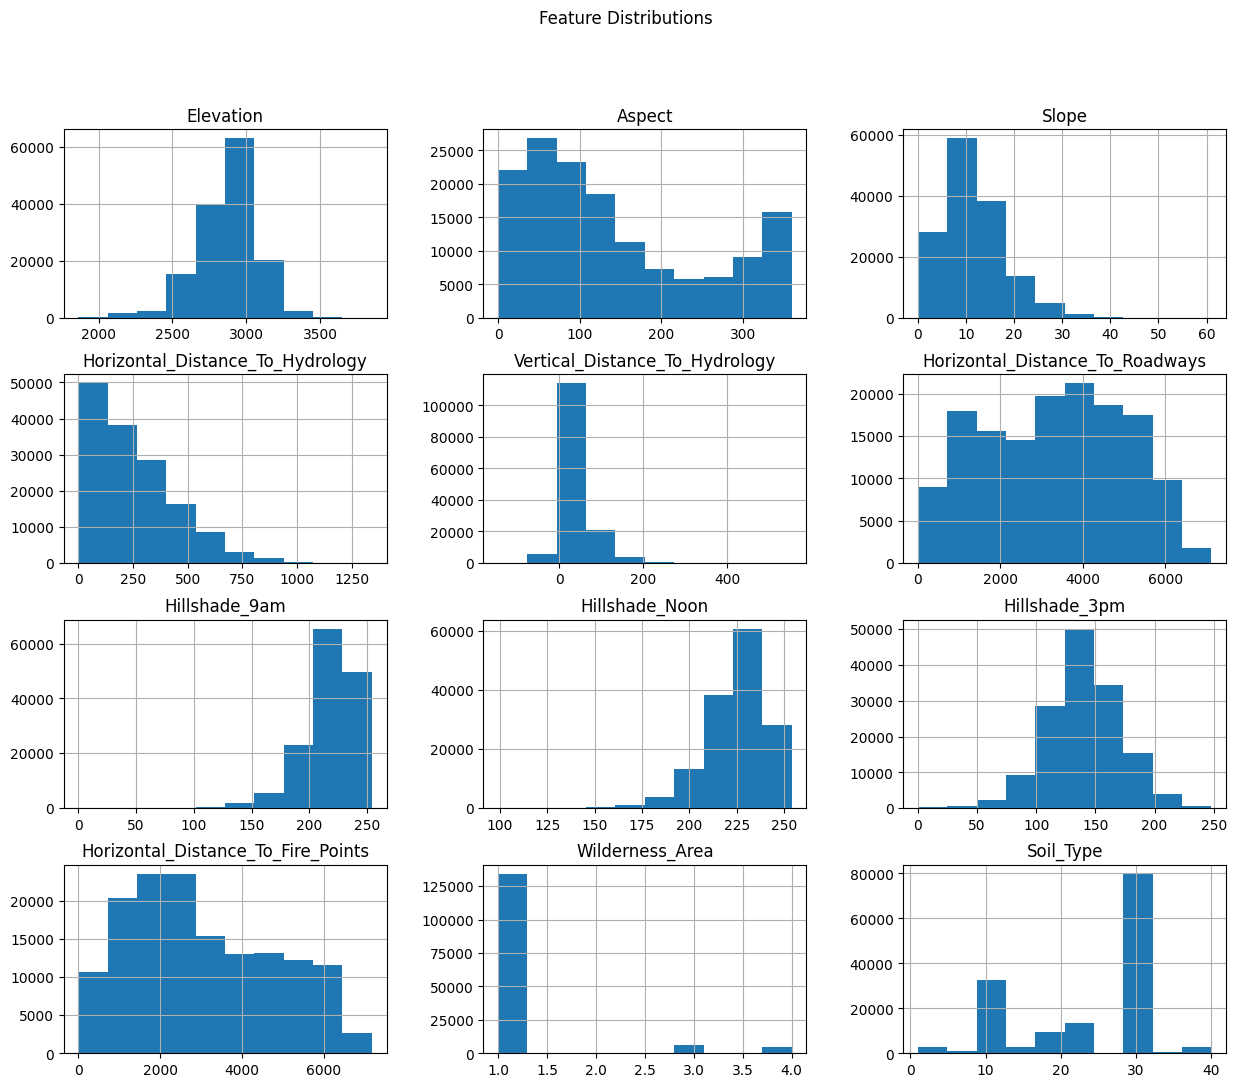

In [ ]:
import matplotlib.pyplot as plt # Histograms (distribution of numeric features)

df.hist(figsize=(15,12))
plt.suptitle("Feature Distributions")
plt.show()

### insights summary
 Landscape Profile: The area is primarily high-altitude and sun-drenched, featuring gentle slopes that generally face away from the south.

Resource Access: Most sites are located very close to water sources, while accessibility to roads and fire-prone zones varies significantly across the region.

Data Consistency: The dataset is heavily concentrated around specific categories, particularly one wilderness area and two dominant soil types, with several extreme outliers in elevation.

### Boxplots (to detect outliers)

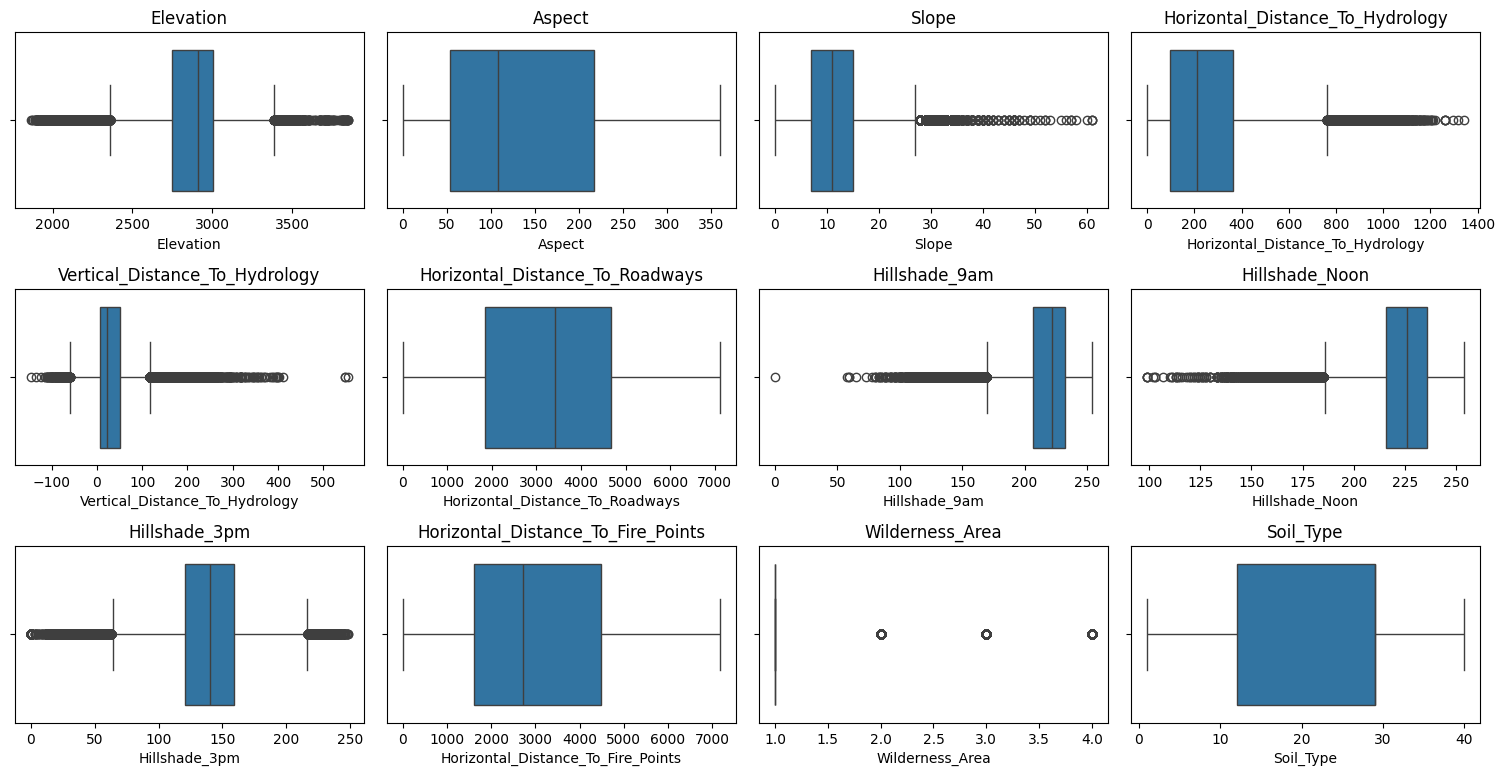

In [ ]:
import seaborn as sns

plt.figure(figsize=(15,10))
for i, col in enumerate(df.select_dtypes(include='number').columns):
    plt.subplot(4, 4, i+1)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

summary-Environmental Profile: Most data points represent high-altitude, sun-drenched areas with gentle slopes, though there are many "outlier" locations at extreme elevations.

Resource Access: While most points are nestled very close to water sources, the distances to roads and fire-prone areas are much more spread out and varied.

Data Distribution: The dataset is heavily lopsided toward a single wilderness area and two specific soil types, which could make it harder to predict the rarer categories.

### Class Imbalance Visualization

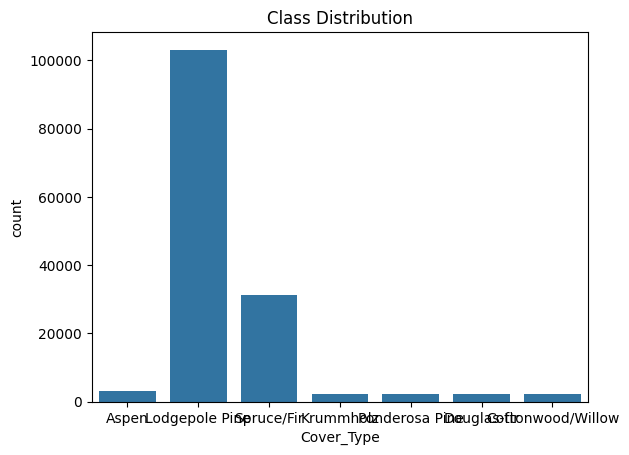

In [ ]:
sns.countplot(x='Cover_Type', data=df)
plt.title("Class Distribution")
plt.show() #this is a highly imbalanced dataset

### Bivariate Analysis (feature vs target) → relation with target


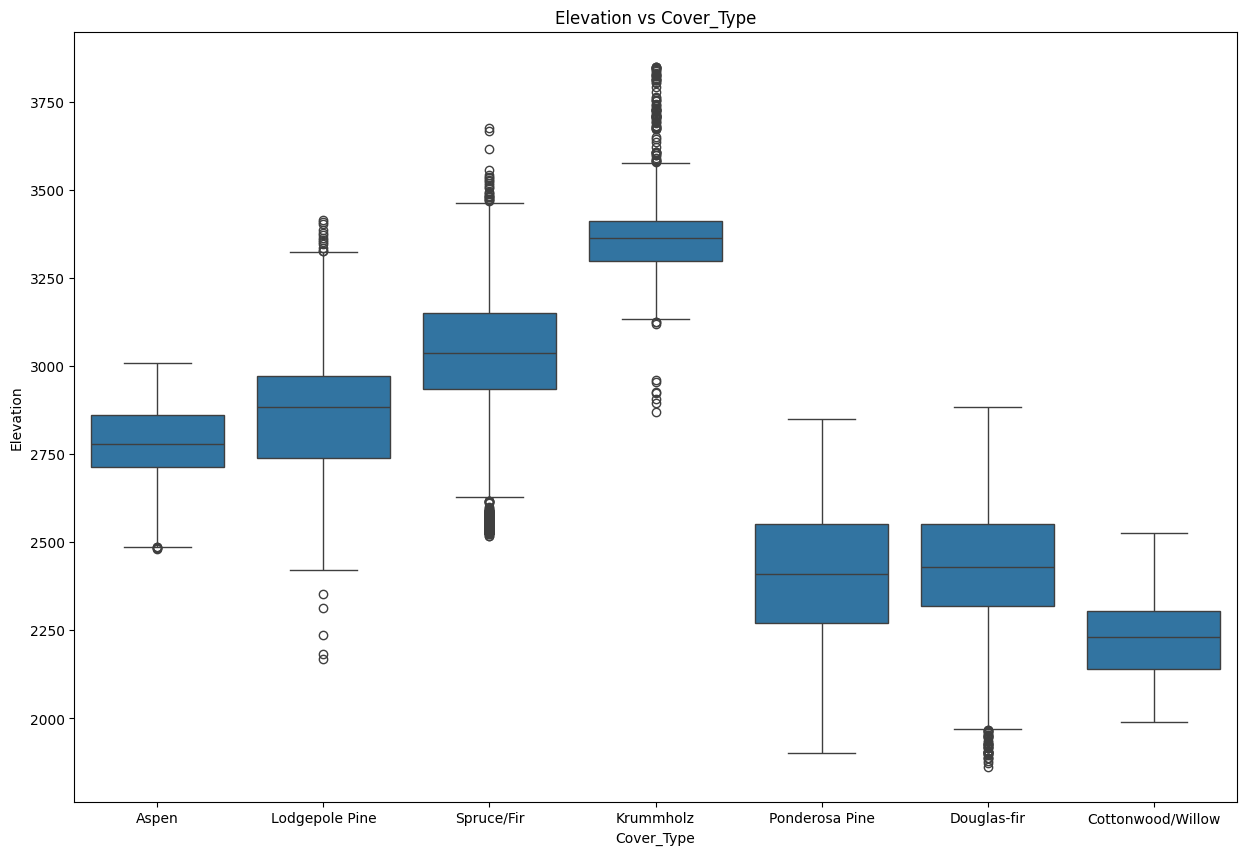

In [ ]:
#Boxplot vs target
plt.figure(figsize=(15,10))
sns.boxplot(x='Cover_Type', y='Elevation', data=df)
plt.title("Elevation vs Cover_Type")
plt.show()

Overall Summary

Vertical Stratification: The forest exhibits clear layering where elevation acts as a primary filter for which tree species can survive.

Species Grouping: Tree types cluster into three main groups: low-dwellers (Cottonwood), mid-range (Pine/Aspen), and high-alpine (Spruce/Krummholz).

Predictive Value: While elevation separates high and low species easily, other environmental factors are necessary to distinguish species within the same altitude "box."

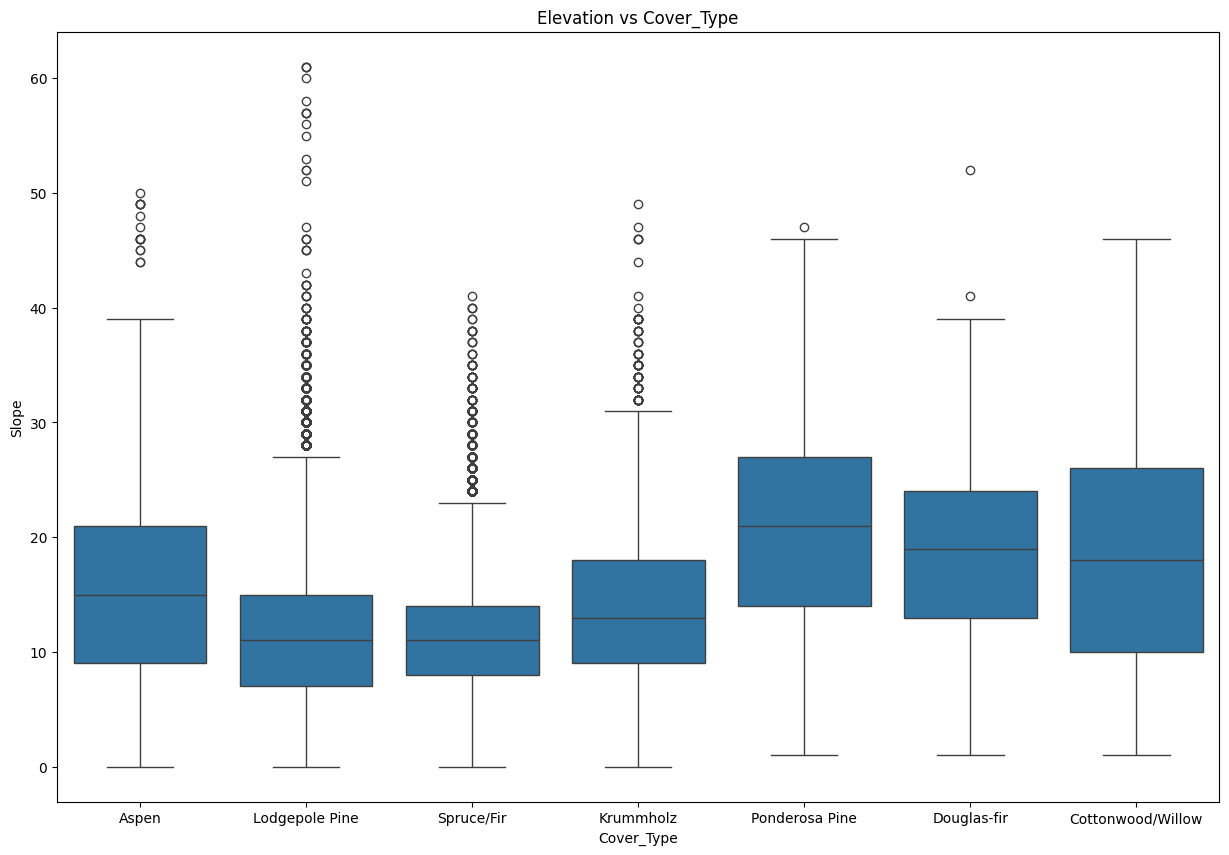

In [ ]:
##box plot with another feature column
plt.figure(figsize=(15,10))
sns.boxplot(x='Cover_Type', y='Slope', data=df)
plt.title("Elevation vs Cover_Type")
plt.show()

### Overall Summary
Preference for Flatness: The most common species (Lodgepole and Spruce/Fir) dominate the gentler, flatter parts of the landscape.

Slope Tolerance: Lower-elevation species (Ponderosa, Douglas-fir) appear much more tolerant of steep, rugged terrain than their high-altitude counterparts.

Variable Predictor: Slope is a helpful secondary feature, but because many species share similar slope ranges, it must be used alongside Elevation for accurate classification.

### Correlation Heatmap → feature relationships

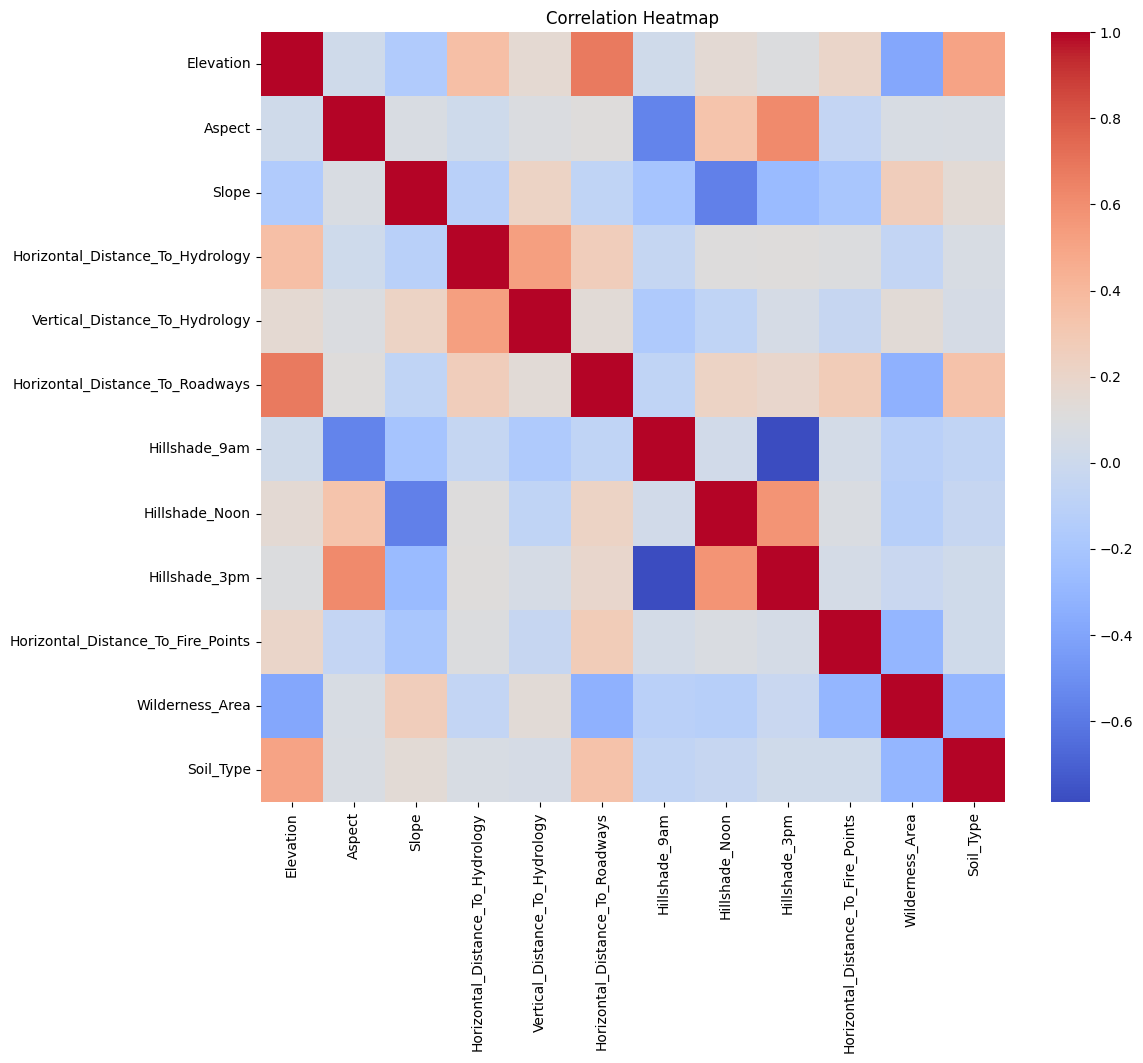

In [ ]:
import numpy as np

corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()



### Overall Summary
Redundant Features: The high correlation between horizontal and vertical distances to water suggests you might only need one of these features to represent "water proximity."

Shadow Dynamics: Sunlight features (Hillshade) are highly interdependent and tied to the direction of the slope, reflecting clear daily solar patterns.

Independent Data: Most other features are "uncorrelated," which is great for machine learning because it means each feature adds a new layer of value without repeating what another feature already says.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pickle #saved in drive

path = "/content/drive/MyDrive/df.pkl"

with open(path, "wb") as f:
    pickle.dump(df, f)

print("File saved successfully!")

File saved successfully!


The cleaned and preprocessed dataset was saved using serialization (pickle) and loaded into a separate notebook for model development to maintain modularity and reproducibility.